# Подготовка датасета Lenta.ru для задачи novelty detection

Цель ноутбука — подготовить датасет для финального проекта **Semantic News Novelty**.

Проектная постановка:

> Система получает поток новостей, группирует публикации по сюжетам и оценивает, добавляет ли новая публикация существенную информацию к уже известному контексту сюжета.

В рамках этой домашней работы ноутбук делает не обучение финальной модели, а именно подготовку и анализ данных:

1. скачивает и распаковывает датасет Lenta.ru;
2. приводит данные к единой схеме;
3. выполняет базовый EDA;
4. проверяет качество и чистоту данных;
5. формирует очищенный датасет новостей;
6. формирует заготовку выборки для дальнейшей ручной разметки novelty;
7. описывает стратегию разметки и валидации.

Важно: Lenta.ru — это хороший корпус для первичного EDA, векторизации и подбора алгоритмов кластеризации, но в нём нет готовой разметки "существенная новая информация / дубль". Поэтому novelty-разметку нужно формировать отдельно на основе кандидатных пар или кандидатных публикаций внутри сюжетных групп.

## 1. Импорты и настройки

Датасет Lenta.ru достаточно большой: около сотен мегабайт в сжатом виде и существенно больше после распаковки. Поэтому в настройках ниже можно ограничить количество строк для быстрого локального запуска.

Для финального прогона можно поставить:

```python
LOAD_FULL_DATASET = True
MAX_ROWS = None
```

In [11]:
from pathlib import Path
import os
import bz2
import shutil
import requests

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 180)

In [ ]:
# Основные пути
PROJECT_ROOT = Path.cwd().resolve().parent

DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
PREPARED_DIR = DATA_DIR / "prepared"

for path in [RAW_DIR, PREPARED_DIR]:
    path.mkdir(parents=True, exist_ok=True)

# Официальный GitHub Release датасета yutkin/Lenta.Ru-News-Dataset.
# Если ссылка изменится, можно скачать файл вручную из Releases проекта и положить в data/raw.
LENTA_BZ2_URL = "https://github.com/yutkin/Lenta.Ru-News-Dataset/releases/download/v1.1/lenta-ru-news.csv.bz2"

LENTA_BZ2_PATH = RAW_DIR / "lenta-ru-news.csv.bz2"
LENTA_CSV_PATH = RAW_DIR / "lenta-ru-news.csv"

# Для быстрого запуска ноутбука можно читать только часть строк.
LOAD_FULL_DATASET = False
MAX_ROWS = 100_000

# Если True — явно распакует .bz2 в .csv. Это может занять время и потребовать несколько ГБ места.
# Для pandas это не обязательно: read_csv умеет читать .bz2 напрямую.
DECOMPRESS_FULL_CSV = False

RANDOM_STATE = 42

print("PROJECT_ROOT:", PROJECT_ROOT)
print("RAW_DIR:", RAW_DIR)
print("PROCESSED_DIR:", PREPARED_DIR)

PROJECT_ROOT: D:\ML\Projects\Git\news-flow-analysis
RAW_DIR: D:\ML\Projects\Git\news-flow-analysis\data\raw
PROCESSED_DIR: D:\ML\Projects\Git\news-flow-analysis\data\processed


## 2. Скачивание и распаковка Lenta.ru

Используется публичный корпус новостей Lenta.ru. В исходном датасете обычно есть поля:

- `url` — ссылка на публикацию;
- `title` — заголовок;
- `text` — текст новости;
- `topic` — широкая тематическая рубрика;
- `tags` — дополнительные теги;
- `date` — дата публикации.

Для нашей задачи важны прежде всего `title`, `text`, `date`, `topic` и `url`.

In [13]:
def download_file(url: str, output_path: Path, chunk_size: int = 1024 * 1024) -> None:
    """Скачивает файл по URL, если его ещё нет локально."""
    if output_path.exists() and output_path.stat().st_size > 0:
        print(f"Файл уже существует: {output_path} ({output_path.stat().st_size / 1024**2:.1f} MB)")
        return

    print(f"Скачиваем: {url}")
    with requests.get(url, stream=True, timeout=60) as response:
        response.raise_for_status()
        total = int(response.headers.get("content-length", 0))
        downloaded = 0
        with open(output_path, "wb") as f:
            for chunk in response.iter_content(chunk_size=chunk_size):
                if chunk:
                    f.write(chunk)
                    downloaded += len(chunk)
                    if total:
                        pct = downloaded / total * 100
                        print(f"\r{downloaded / 1024**2:.1f} / {total / 1024**2:.1f} MB ({pct:.1f}%)", end="")
    print(f"\nГотово: {output_path}")

In [14]:
# Если интернет в окружении доступен, эта ячейка скачает датасет.
# Если нет — скачайте файл lenta-ru-news.csv.bz2 вручную и положите его в data/raw.
try:
    download_file(LENTA_BZ2_URL, LENTA_BZ2_PATH)
except Exception as e:
    print("Не удалось скачать файл автоматически.")
    print("Положите lenta-ru-news.csv.bz2 вручную в папку data/raw и перезапустите ноутбук.")
    print("Ошибка:", repr(e))

Файл уже существует: D:\ML\Projects\Git\news-flow-analysis\data\raw\lenta-ru-news.csv.bz2 (330.0 MB)


In [15]:
def decompress_bz2(input_path: Path, output_path: Path) -> None:
    """Явно распаковывает .bz2 в .csv."""
    if output_path.exists() and output_path.stat().st_size > 0:
        print(f"Распакованный CSV уже существует: {output_path} ({output_path.stat().st_size / 1024**3:.2f} GB)")
        return

    if not input_path.exists():
        raise FileNotFoundError(f"Не найден архив: {input_path}")

    print(f"Распаковываем {input_path} -> {output_path}")
    with bz2.open(input_path, "rb") as src, open(output_path, "wb") as dst:
        shutil.copyfileobj(src, dst)
    print(f"Готово: {output_path} ({output_path.stat().st_size / 1024**3:.2f} GB)")

if DECOMPRESS_FULL_CSV:
    decompress_bz2(LENTA_BZ2_PATH, LENTA_CSV_PATH)
else:
    print("Явная распаковка отключена. pandas будет читать .bz2 напрямую.")

Явная распаковка отключена. pandas будет читать .bz2 напрямую.


## 3. Загрузка данных

Для экономии места и времени можно читать `.bz2` напрямую. Если включена явная распаковка, можно читать `.csv`.

In [16]:
if LENTA_CSV_PATH.exists():
    input_path = LENTA_CSV_PATH
    compression = None
elif LENTA_BZ2_PATH.exists():
    input_path = LENTA_BZ2_PATH
    compression = "bz2"
else:
    raise FileNotFoundError("Не найден ни распакованный CSV, ни .bz2 архив Lenta.ru")

nrows = None if LOAD_FULL_DATASET else MAX_ROWS

raw_df = pd.read_csv(input_path, compression=compression, nrows=nrows)
print(raw_df.shape)
raw_df.head()

(100000, 6)


,url,title,text,topic,tags,date
0,https://lenta.ru/news/1914/09/16/hungarnn/,1914. Русские войска вступили в пределы Венгрии,"Бои у Сопоцкина и Друскеник закончились отступлением германцев. Неприятель, приблизившись с севера к Осовцу начал артиллерийскую борьбу с крепостью. В артиллерийском бою приним...",Библиотека,Первая мировая,1914/09/16
1,https://lenta.ru/news/1914/09/16/lermontov/,1914. Празднование столетия М.Ю. Лермонтова отложено,"Министерство народного просвещения, в виду происходящих чрезвычайных событий, признало соответственным в день годовщины со дня рождения М.Ю. Лермонтова (2-го октября 1914 года)...",Библиотека,Первая мировая,1914/09/16
2,https://lenta.ru/news/1914/09/17/nesteroff/,1914. Das ist Nesteroff!,"Штабс-капитан П. Н. Нестеров на днях, увидев в районе Желтиева, в Галиции, летящий над нашим расположением австрийский аэроплан, собиравшийся бросить бомбы, взлетел на воздух, ...",Библиотека,Первая мировая,1914/09/17
3,https://lenta.ru/news/1914/09/17/bulldogn/,1914. Бульдог-гонец под Льежем,"Фотограф-корреспондент Daily Mirror рассказывает случай, который порадует всех друзей животных. Лейтенант бельгийской артиллерии, руководивший обороной одного из фортов Льежа, ...",Библиотека,Первая мировая,1914/09/17
4,https://lenta.ru/news/1914/09/18/zver/,1914. Под Люблином пойман швабский зверь,"Лица, приехавшие в Варшаву из Люблина, передают, что туда доставлен «швабский зверь» — взятый в плен прусский майор Прейскер, бывший комендант Калиша. Это — здоровый детина, с ...",Библиотека,Первая мировая,1914/09/18


In [17]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 6 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   url     100000 non-null  object
 1   title   100000 non-null  object
 2   text    100000 non-null  object
 3   topic   100000 non-null  object
 4   tags    99999 non-null   object
 5   date    100000 non-null  object
dtypes: object(6)
memory usage: 4.6+ MB


## 4. Приведение к единой схеме

Дальше используем единую схему колонок:

- `news_id` — внутренний идентификатор;
- `url` — ссылка;
- `title` — заголовок;
- `text` — текст;
- `topic` — широкая рубрика;
- `tags` — теги;
- `published_at` — дата публикации;
- `text_length` — длина текста в символах;
- `text_num_words` — число слов в тексте.

Названия `text_length` и `text_num_words` используются как стандартные для дальнейших ноутбуков проекта.

In [18]:
def normalize_lenta_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # В датасете Lenta.ru дата обычно называется date.
    if "date" in df.columns and "published_at" not in df.columns:
        df = df.rename(columns={"date": "published_at"})

    required_cols = ["title", "text", "published_at"]
    missing_required = [col for col in required_cols if col not in df.columns]
    if missing_required:
        raise ValueError(f"В датасете не найдены обязательные колонки: {missing_required}")

    if "url" not in df.columns:
        df["url"] = np.nan
    if "topic" not in df.columns:
        df["topic"] = "unknown"
    if "tags" not in df.columns:
        df["tags"] = "unknown"

    df["news_id"] = np.arange(len(df))
    df["published_at"] = pd.to_datetime(df["published_at"], errors="coerce")

    df["title"] = df["title"].fillna("").astype(str)
    df["text"] = df["text"].fillna("").astype(str)
    df["topic"] = df["topic"].fillna("unknown").astype(str)
    df["tags"] = df["tags"].fillna("unknown").astype(str)

    df["text_length"] = df["text"].str.len()
    df["text_num_words"] = df["text"].str.split().str.len()
    df["title_length"] = df["title"].str.len()
    df["title_num_words"] = df["title"].str.split().str.len()

    return df

news_df = normalize_lenta_columns(raw_df)
news_df.head()

,url,title,text,topic,tags,published_at,news_id,text_length,text_num_words,title_length,title_num_words
0,https://lenta.ru/news/1914/09/16/hungarnn/,1914. Русские войска вступили в пределы Венгрии,"Бои у Сопоцкина и Друскеник закончились отступлением германцев. Неприятель, приблизившись с севера к Осовцу начал артиллерийскую борьбу с крепостью. В артиллерийском бою приним...",Библиотека,Первая мировая,1914-09-16,0,901,118,49,7
1,https://lenta.ru/news/1914/09/16/lermontov/,1914. Празднование столетия М.Ю. Лермонтова отложено,"Министерство народного просвещения, в виду происходящих чрезвычайных событий, признало соответственным в день годовщины со дня рождения М.Ю. Лермонтова (2-го октября 1914 года)...",Библиотека,Первая мировая,1914-09-16,1,346,43,53,6
2,https://lenta.ru/news/1914/09/17/nesteroff/,1914. Das ist Nesteroff!,"Штабс-капитан П. Н. Нестеров на днях, увидев в районе Желтиева, в Галиции, летящий над нашим расположением австрийский аэроплан, собиравшийся бросить бомбы, взлетел на воздух, ...",Библиотека,Первая мировая,1914-09-17,2,1923,263,24,4
3,https://lenta.ru/news/1914/09/17/bulldogn/,1914. Бульдог-гонец под Льежем,"Фотограф-корреспондент Daily Mirror рассказывает случай, который порадует всех друзей животных. Лейтенант бельгийской артиллерии, руководивший обороной одного из фортов Льежа, ...",Библиотека,Первая мировая,1914-09-17,3,703,99,31,4
4,https://lenta.ru/news/1914/09/18/zver/,1914. Под Люблином пойман швабский зверь,"Лица, приехавшие в Варшаву из Люблина, передают, что туда доставлен «швабский зверь» — взятый в плен прусский майор Прейскер, бывший комендант Калиша. Это — здоровый детина, с ...",Библиотека,Первая мировая,1914-09-18,4,754,115,40,6


## 5. Первичный EDA и качество данных

На этом этапе проверяем не все возможные статистики, а только то, что важно для будущего моделирования:

- есть ли пропуски в ключевых полях;
- есть ли дубли;
- есть ли слишком короткие тексты;
- корректно ли распарсились даты;
- как распределены рубрики и источники;
- как распределены новости во времени.

In [19]:
print("Размер датасета:", news_df.shape)
news_df.head(3)

Размер датасета: (100000, 11)


,url,title,text,topic,tags,published_at,news_id,text_length,text_num_words,title_length,title_num_words
0,https://lenta.ru/news/1914/09/16/hungarnn/,1914. Русские войска вступили в пределы Венгрии,"Бои у Сопоцкина и Друскеник закончились отступлением германцев. Неприятель, приблизившись с севера к Осовцу начал артиллерийскую борьбу с крепостью. В артиллерийском бою приним...",Библиотека,Первая мировая,1914-09-16,0,901,118,49,7
1,https://lenta.ru/news/1914/09/16/lermontov/,1914. Празднование столетия М.Ю. Лермонтова отложено,"Министерство народного просвещения, в виду происходящих чрезвычайных событий, признало соответственным в день годовщины со дня рождения М.Ю. Лермонтова (2-го октября 1914 года)...",Библиотека,Первая мировая,1914-09-16,1,346,43,53,6
2,https://lenta.ru/news/1914/09/17/nesteroff/,1914. Das ist Nesteroff!,"Штабс-капитан П. Н. Нестеров на днях, увидев в районе Желтиева, в Галиции, летящий над нашим расположением австрийский аэроплан, собиравшийся бросить бомбы, взлетел на воздух, ...",Библиотека,Первая мировая,1914-09-17,2,1923,263,24,4


In [20]:
missing_share = news_df.isna().mean().sort_values(ascending=False)
missing_share[missing_share > 0]

Series([], dtype: float64)

In [21]:
quality_report = pd.DataFrame({
    "metric": [
        "rows",
        "empty_text",
        "empty_title",
        "invalid_published_at",
        "duplicated_full_rows",
        "duplicated_text",
        "duplicated_url_non_null",
        "texts_less_20_words",
    ],
    "value": [
        len(news_df),
        (news_df["text"].str.strip() == "").sum(),
        (news_df["title"].str.strip() == "").sum(),
        news_df["published_at"].isna().sum(),
        news_df.duplicated().sum(),
        news_df["text"].duplicated().sum(),
        news_df.loc[news_df["url"].notna(), "url"].duplicated().sum(),
        (news_df["text_num_words"] < 20).sum(),
    ]
})
quality_report

,metric,value
0,rows,100000
1,empty_text,0
2,empty_title,0
3,invalid_published_at,0
4,duplicated_full_rows,0
5,duplicated_text,187
6,duplicated_url_non_null,11
7,texts_less_20_words,377


### Вывод по чистоте данных

Для задачи семантической векторизации особенно критичны:

1. пустые тексты;
2. некорректные даты;
3. полные дубли текстов;
4. слишком короткие публикации.

Пустые и очень короткие тексты дают нестабильные эмбеддинги. Некорректные даты мешают использовать временную логику, а дубли искажают оценку кластеризации и novelty detection.

## 6. Базовая очистка

Очистка намеренно простая: мы не делаем глубокую обработку признаков, лемматизацию или сложную фильтрацию. Главная цель — получить пригодный корпус новостей для дальнейшей векторизации и разметки.

In [22]:
def clean_news(df: pd.DataFrame, min_words: int = 20) -> pd.DataFrame:
    df = df.copy()

    before = len(df)

    df = df.dropna(subset=["published_at"])
    df = df[df["text"].str.strip() != ""]
    df = df[df["title"].str.strip() != ""]
    df = df[df["text_num_words"] >= min_words]

    # Удаляем полные текстовые дубли.
    df = df.drop_duplicates(subset=["text"])

    # Если URL есть, он тоже должен быть уникальным.
    if "url" in df.columns:
        df = df.sort_values("published_at")
        df = df.drop_duplicates(subset=["url"], keep="first")

    df = df.sort_values("published_at").reset_index(drop=True)
    df["news_id"] = np.arange(len(df))

    after = len(df)
    print(f"Было строк: {before}")
    print(f"Стало строк: {after}")
    print(f"Удалено строк: {before - after} ({(before - after) / before:.2%})")

    return df

clean_df = clean_news(news_df, min_words=20)
clean_df.head()

Было строк: 100000
Стало строк: 99608
Удалено строк: 392 (0.39%)


,url,title,text,topic,tags,published_at,news_id,text_length,text_num_words,title_length,title_num_words
0,https://lenta.ru/news/1914/09/16/hungarnn/,1914. Русские войска вступили в пределы Венгрии,"Бои у Сопоцкина и Друскеник закончились отступлением германцев. Неприятель, приблизившись с севера к Осовцу начал артиллерийскую борьбу с крепостью. В артиллерийском бою приним...",Библиотека,Первая мировая,1914-09-16,0,901,118,49,7
1,https://lenta.ru/news/1914/09/16/lermontov/,1914. Празднование столетия М.Ю. Лермонтова отложено,"Министерство народного просвещения, в виду происходящих чрезвычайных событий, признало соответственным в день годовщины со дня рождения М.Ю. Лермонтова (2-го октября 1914 года)...",Библиотека,Первая мировая,1914-09-16,1,346,43,53,6
2,https://lenta.ru/news/1914/09/17/nesteroff/,1914. Das ist Nesteroff!,"Штабс-капитан П. Н. Нестеров на днях, увидев в районе Желтиева, в Галиции, летящий над нашим расположением австрийский аэроплан, собиравшийся бросить бомбы, взлетел на воздух, ...",Библиотека,Первая мировая,1914-09-17,2,1923,263,24,4
3,https://lenta.ru/news/1914/09/17/bulldogn/,1914. Бульдог-гонец под Льежем,"Фотограф-корреспондент Daily Mirror рассказывает случай, который порадует всех друзей животных. Лейтенант бельгийской артиллерии, руководивший обороной одного из фортов Льежа, ...",Библиотека,Первая мировая,1914-09-17,3,703,99,31,4
4,https://lenta.ru/news/1914/09/18/zver/,1914. Под Люблином пойман швабский зверь,"Лица, приехавшие в Варшаву из Люблина, передают, что туда доставлен «швабский зверь» — взятый в плен прусский майор Прейскер, бывший комендант Калиша. Это — здоровый детина, с ...",Библиотека,Первая мировая,1914-09-18,4,754,115,40,6


## 7. EDA, важный для моделирования

### 7.1 Длины текстов и заголовков

Длина текста важна для выбора стратегии векторизации. Слишком короткие тексты могут не содержать достаточного контекста, а слишком длинные будут обрезаться transformer-моделью.

In [23]:
clean_df[["text_length", "text_num_words", "title_length", "title_num_words"]].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])

,text_length,text_num_words,title_length,title_num_words
count,99608.000000,99608.000000,99608.000000,99608.000000
mean,1191.045157,159.275570,56.255732,7.612591
std,608.998795,83.057931,13.122708,1.940901
min,131.000000,20.000000,15.000000,2.000000
1%,365.000000,48.000000,29.000000,4.000000
5%,497.000000,66.000000,36.000000,5.000000
25%,783.000000,104.000000,47.000000,6.000000
50%,1072.000000,143.000000,56.000000,7.000000
75%,1460.000000,195.000000,65.000000,9.000000
95%,2298.000000,308.000000,79.000000,11.000000


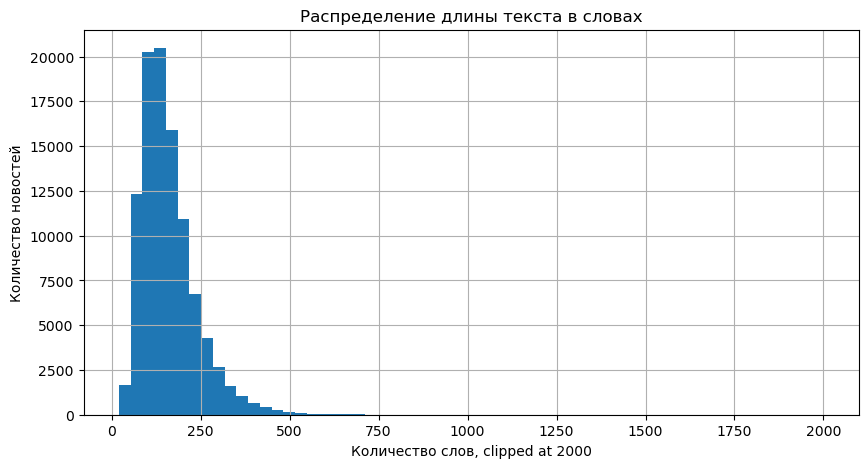

In [24]:
plt.figure(figsize=(10, 5))
clean_df["text_num_words"].clip(upper=2000).hist(bins=60)
plt.title("Распределение длины текста в словах")
plt.xlabel("Количество слов, clipped at 2000")
plt.ylabel("Количество новостей")
plt.show()

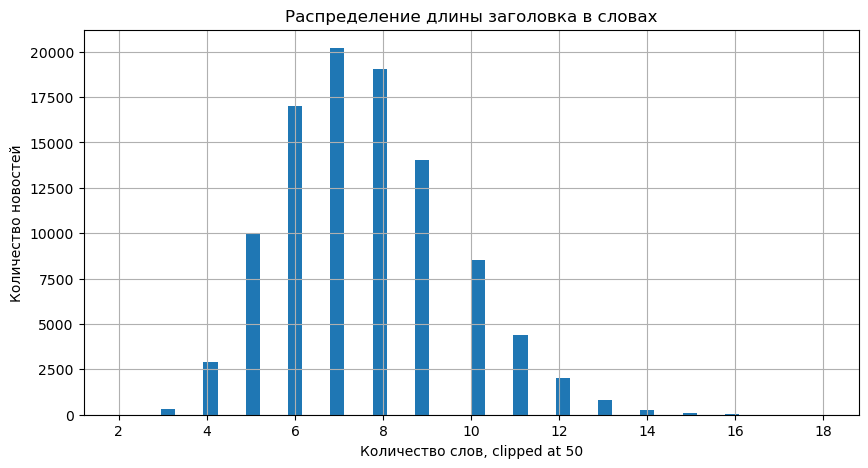

In [25]:
plt.figure(figsize=(10, 5))
clean_df["title_num_words"].clip(upper=50).hist(bins=50)
plt.title("Распределение длины заголовка в словах")
plt.xlabel("Количество слов, clipped at 50")
plt.ylabel("Количество новостей")
plt.show()

### 7.2 Распределение по темам

Поле `topic` в Lenta.ru — это широкая рубрика. Для проекта оно не является финальным сюжетным кластером: рубрика слишком крупная. Но она полезна как верхний уровень навигации и как способ ограничить область поиска кандидатов.

In [26]:
topic_counts = clean_df["topic"].value_counts()
topic_counts.head(30)

topic
Россия               38326
Мир                  29488
Экономика             9776
Спорт                 6666
Культура              6288
Интернет и СМИ        5920
Из жизни              2885
Наука и техника        252
Библиотека               5
Силовые структуры        1
Бывший СССР              1
Name: count, dtype: int64

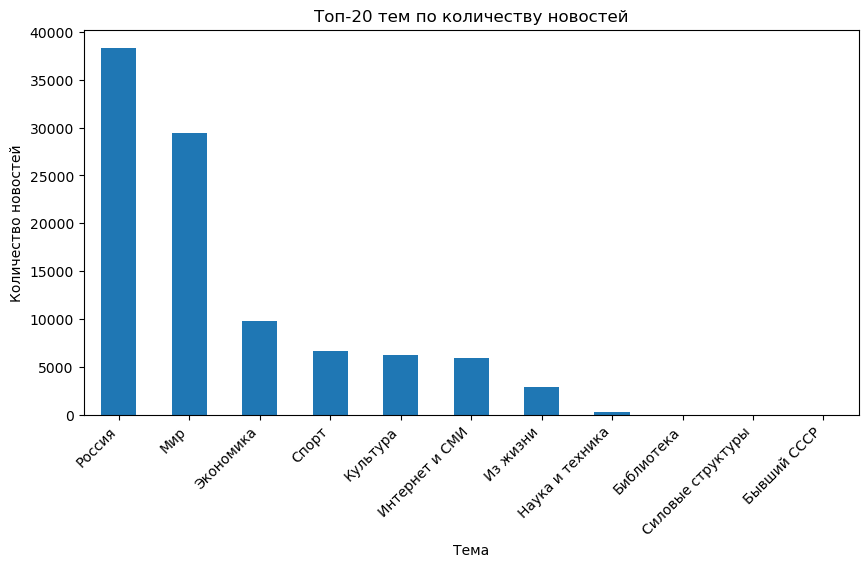

In [27]:
plt.figure(figsize=(10, 5))
topic_counts.head(20).plot(kind="bar")
plt.title("Топ-20 тем по количеству новостей")
plt.xlabel("Тема")
plt.ylabel("Количество новостей")
plt.xticks(rotation=45, ha="right")
plt.show()

### 7.3 Распределение по времени

Так как будущая система работает с новостным потоком, временное распределение критично для выбора temporal window и стратегии валидации.

In [28]:
print("Минимальная дата:", clean_df["published_at"].min())
print("Максимальная дата:", clean_df["published_at"].max())

Минимальная дата: 1914-09-16 00:00:00
Максимальная дата: 2004-08-31 00:00:00


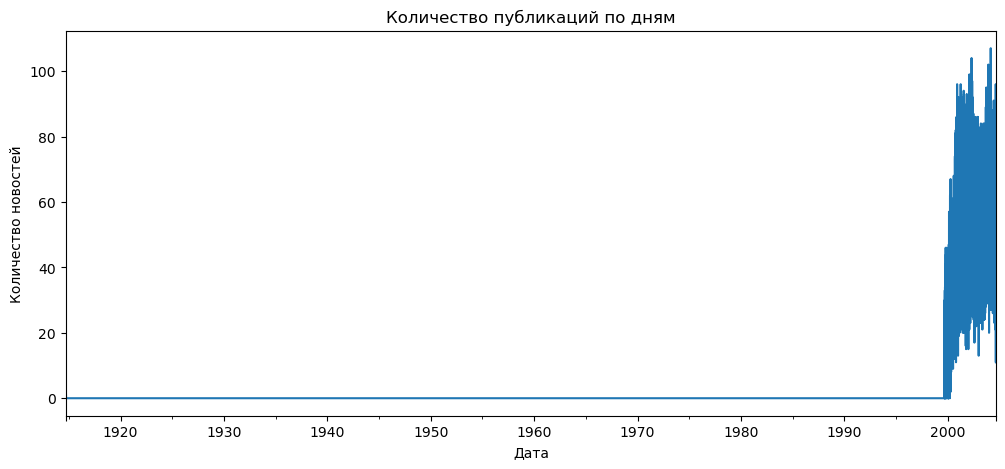

In [29]:
daily_counts = clean_df.set_index("published_at").resample("D").size()

plt.figure(figsize=(12, 5))
daily_counts.plot()
plt.title("Количество публикаций по дням")
plt.xlabel("Дата")
plt.ylabel("Количество новостей")
plt.show()

### 7.4 Корреляции технических числовых признаков

Это текстовая задача, поэтому классические линейные корреляции на сырых данных имеют ограниченную ценность. Тем не менее полезно проверить технические числовые признаки: длину текста и заголовка.

In [30]:
numeric_cols = ["text_length", "text_num_words", "title_length", "title_num_words"]
clean_df[numeric_cols].corr()

,text_length,text_num_words,title_length,title_num_words
text_length,1.000000,0.992251,0.140945,0.112900
text_num_words,0.992251,1.000000,0.131632,0.121729
title_length,0.140945,0.131632,1.000000,0.805549
title_num_words,0.112900,0.121729,0.805549,1.000000


Ожидаемый вывод: сильная корреляция между `text_length` и `text_num_words` не является проблемой. Эти признаки нужны в первую очередь для контроля качества данных, а не как основные признаки модели.

## 8. Нужно ли масштабирование

Для текущей постановки классическое масштабирование признаков не требуется.

Причины:

1. Основной вход модели — текст, а не числовая таблица.
2. Текст будет преобразован в embedding-векторы с помощью sentence-transformer.
3. Для cosine similarity важна не стандартизация через `StandardScaler`, а L2-нормализация embedding-векторов.
4. Для rule-based decision layer масштабирование similarity-признаков не требуется, так как они уже находятся в сопоставимом диапазоне.

Если в дальнейшем поверх similarity-признаков будет обучаться отдельный классификатор, необходимость масштабирования будет зависеть от алгоритма. Например, для Logistic Regression масштабирование может быть полезно, а для деревьев решений — обычно нет.

## 9. Формирование очищенного корпуса новостей

На этом этапе сохраняем очищенный корпус. Это ещё не финальная novelty-выборка, а базовый датасет новостей, из которого дальше строятся эмбеддинги, кластеры и кандидаты на ручную разметку.

In [31]:
news_output_cols = [
    "news_id",
    "url",
    "title",
    "text",
    "topic",
    "tags",
    "published_at",
    "text_length",
    "text_num_words",
    "title_length",
    "title_num_words",
]

clean_news_path = PROCESSED_DIR / "lenta_clean_news.csv"
clean_df[news_output_cols].to_csv(clean_news_path, index=False)
clean_news_path

WindowsPath('D:/ML/Projects/Git/news-flow-analysis/data/processed/lenta_clean_news.csv')

## 10. Заготовка выборки для разметки novelty

В Lenta.ru нет готовой разметки существенной новизны. Поэтому нужно сформировать пул кандидатов для ручной разметки.

Единица будущей novelty-выборки:

```text
candidate_news внутри story/context → label
```

На первом приближении можно формировать пары похожих новостей:

```text
previous_news, candidate_news → label
```

Где label:

- `1` — кандидат добавляет существенную новую информацию;
- `0` — дубль, рерайт или несущественное обновление.

Ниже формируется небольшой annotation pool на базе TF-IDF по заголовку и началу текста. Это не финальная модель, а только технический способ подобрать похожие новости для ручной разметки.

In [32]:
# Настройки формирования пула для разметки
ANNOTATION_SAMPLE_SIZE = 10_000
ANNOTATION_TOPICS = None  # например: ["Россия", "Мир", "Экономика"] или None для всех тем
ANNOTATION_TIME_WINDOW_DAYS = 14
ANNOTATION_MAX_PAIRS = 2_000

# Для TF-IDF берём заголовок + начало текста, чтобы быстро подобрать похожие кандидаты.
TEXT_PREFIX_CHARS = 1000

In [33]:
def build_annotation_pool(
    df: pd.DataFrame,
    sample_size: int = 10_000,
    time_window_days: int = 14,
    max_pairs: int = 2_000,
    topics=None,
    random_state: int = 42,
) -> pd.DataFrame:
    work = df.copy()

    if topics is not None:
        work = work[work["topic"].isin(topics)]

    # Берём последние новости из сэмпла, чтобы сохранить временную природу задачи.
    work = work.sort_values("published_at").tail(sample_size).reset_index(drop=True)

    work["retrieval_text"] = (
        work["title"].fillna("") + ". " + work["text"].fillna("").str.slice(0, TEXT_PREFIX_CHARS)
    )

    vectorizer = TfidfVectorizer(
        max_features=50_000,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.9,
    )
    X = vectorizer.fit_transform(work["retrieval_text"])

    pairs = []
    window = pd.Timedelta(days=time_window_days)

    # Идём по времени: для каждой candidate_news ищем похожую previous_news только в прошлом.
    for idx in range(len(work)):
        candidate = work.iloc[idx]
        candidate_time = candidate["published_at"]

        prev_mask = (
            (work.index < idx)
            & (work["published_at"] >= candidate_time - window)
        )

        # Рубрика — грубое ограничение области поиска. Это не story cluster.
        if "topic" in work.columns:
            prev_mask = prev_mask & (work["topic"] == candidate["topic"])

        prev_indices = np.where(prev_mask)[0]
        if len(prev_indices) == 0:
            continue

        sims = cosine_similarity(X[idx], X[prev_indices]).ravel()
        best_local = int(np.argmax(sims))
        best_idx = int(prev_indices[best_local])
        best_sim = float(sims[best_local])

        # Отсекаем совсем непохожие пары, чтобы разметчик не тратил время.
        if best_sim < 0.1:
            continue

        previous = work.iloc[best_idx]
        pairs.append({
            "previous_news_id": previous["news_id"],
            "candidate_news_id": candidate["news_id"],
            "previous_published_at": previous["published_at"],
            "candidate_published_at": candidate["published_at"],
            "time_delta_hours": (candidate["published_at"] - previous["published_at"]).total_seconds() / 3600,
            "topic": candidate["topic"],
            "previous_title": previous["title"],
            "candidate_title": candidate["title"],
            "previous_text": previous["text"],
            "candidate_text": candidate["text"],
            "tfidf_similarity": best_sim,
            "label": np.nan,  # заполняется вручную: 0/1
        })

        if len(pairs) >= max_pairs:
            break

    return pd.DataFrame(pairs)

annotation_pool = build_annotation_pool(
    clean_df,
    sample_size=ANNOTATION_SAMPLE_SIZE,
    time_window_days=ANNOTATION_TIME_WINDOW_DAYS,
    max_pairs=ANNOTATION_MAX_PAIRS,
    topics=ANNOTATION_TOPICS,
    random_state=RANDOM_STATE,
)

annotation_pool.shape

(2000, 12)

In [34]:
annotation_pool[[
    "previous_published_at",
    "candidate_published_at",
    "time_delta_hours",
    "topic",
    "tfidf_similarity",
    "previous_title",
    "candidate_title",
    "label",
]].head(20)

,previous_published_at,candidate_published_at,time_delta_hours,topic,tfidf_similarity,previous_title,candidate_title,label
0,2004-03-16,2004-03-16,0.0,Россия,0.251806,"Взрыв в жилом доме Архангельска: 4 человека погибли, 75 под завалами",В Архангельске обрушился 9-этажный жилой дом,NaN
1,2004-03-16,2004-03-17,24.0,Россия,0.162973,"Взрыв в жилом доме Архангельска: 4 человека погибли, 75 под завалами",Взрыв в жилом доме Архангельска произошел на втором или третьем этажах,NaN
2,2004-03-16,2004-03-17,24.0,Мир,0.213927,"Полиция идентифицировала ""огайского снайпера""","Предполагаемый ""снайпер из Огайо"" арестован в Лас-Вегасе",NaN
3,2004-03-17,2004-03-17,0.0,Мир,0.246557,К Виталию Калоеву пустили российского адвоката,Спикера парламента Северной Осетии не пускают к больному Виталию Калоеву,NaN
4,2004-03-16,2004-03-17,24.0,Россия,0.101676,"Взрыв в жилом доме Архангельска: 4 человека погибли, 75 под завалами","""Илим Палп"" выделяет пострадавшим при взрыве в Архангельске два миллиона рублей",NaN
5,2004-03-16,2004-03-17,24.0,Россия,0.427434,"""Бойцы Мовсара Бараева"" угрожают Франции терактами","Французские спецслужбы не узнали исламистов в ""бойцах Мовсара Бараева""",NaN
6,2004-03-17,2004-03-17,0.0,Россия,0.384367,Взрыв в жилом доме Архангельска произошел на втором или третьем этажах,На месте взрыва дома в Архангельске найдена газовая труба со свинченной заглушкой,NaN
7,2004-03-16,2004-03-17,24.0,Россия,0.351722,"Взрыв в жилом доме Архангельска: 4 человека погибли, 75 под завалами",Число погибших в Архангельске выросло до 47 человек. Под завалами могут оставаться еще 20,NaN
8,2004-03-17,2004-03-17,0.0,Россия,0.115837,Госсовет Чечни сделал инспектора Счетной палаты премьером республики,Грызлов возглавил Парламентское собрание союза Белоруссии и России,NaN
9,2004-03-17,2004-03-17,0.0,Мир,0.289929,В центре Багдада взорван отель,Из под обломков взорванной в центре Багдада гостиницы извлечены тела 27 человек,NaN


In [ ]:
annotation_pool_path = PREPARED_DIR / "lenta_novelty_annotation_pool.csv"
annotation_pool.to_csv(annotation_pool_path, index=False)
annotation_pool_path

WindowsPath('D:/ML/Projects/Git/news-flow-analysis/data/annotation/lenta_novelty_annotation_pool.csv')

### Почему это не финальная модель

TF-IDF здесь используется только для формирования кандидатов на ручную разметку. В финальной системе основной ML-компонент — sentence-transformer encoder, который строит семантические embedding-векторы.

После ручной разметки можно будет сформировать финальный датасет:

```text
candidate_news_id
cluster_id / context_id
cluster_similarity
max_recent_similarity
max_significant_similarity
label
```

Где similarity-признаки будут рассчитаны уже поверх embedding-модели, а не TF-IDF.

## 11. Оценка качества разметки

Разметка novelty частично субъективна. Граница между "незначительным обновлением" и "существенной новой информацией" может зависеть от редакционной политики.

Предлагаемая схема контроля качества:

1. Начать с бинарной разметки:
   - `0` — дубль, рерайт или несущественное обновление;
   - `1` — существенное обновление, добавляющее новый факт к сюжету.
2. Составить инструкцию для разметчиков с примерами.
3. 10–20% выборки разметить двумя независимыми разметчиками.
4. Посчитать Cohen's Kappa.
5. Если согласованность низкая, уточнить инструкцию и повторно разметить спорные случаи.

Целевой ориентир: `Cohen's Kappa >= 0.6`. Если ниже — критерии существенности недостаточно однозначны.

In [36]:
# Пример кода для оценки согласованности разметчиков.
# В реальной разметке нужно иметь две колонки: label_annotator_1 и label_annotator_2.

from sklearn.metrics import cohen_kappa_score

if {"label_annotator_1", "label_annotator_2"}.issubset(annotation_pool.columns):
    labeled = annotation_pool.dropna(subset=["label_annotator_1", "label_annotator_2"])
    kappa = cohen_kappa_score(labeled["label_annotator_1"], labeled["label_annotator_2"])
    print(f"Cohen's Kappa: {kappa:.3f}")
else:
    print("Колонки label_annotator_1 и label_annotator_2 пока отсутствуют. Этот блок используется после двойной разметки.")

Колонки label_annotator_1 и label_annotator_2 пока отсутствуют. Этот блок используется после двойной разметки.


## 12. Стратегия валидации

Для новостного потока нельзя ограничиваться случайным train/test split.

Проблемы random split:

1. новости одного сюжета могут попасть одновременно в train и test;
2. это создаёт утечку данных;
3. качество будет завышено относительно реального сценария.

Основная стратегия — temporal split:

```text
train: более ранние публикации
validation/test: более поздние публикации
```

Такой подход соответствует production-сценарию: система настраивается на исторических данных и применяется к новым новостям.

In [37]:
# Temporal split для очищенного корпуса.
# Для финальной размеченной novelty-выборки логика будет такой же.

split_date = clean_df["published_at"].quantile(0.8)

train_df = clean_df[clean_df["published_at"] <= split_date]
test_df = clean_df[clean_df["published_at"] > split_date]

print("split_date:", split_date)
print("train:", train_df.shape)
print("test:", test_df.shape)
print("train dates:", train_df["published_at"].min(), "—", train_df["published_at"].max())
print("test dates:", test_df["published_at"].min(), "—", test_df["published_at"].max())

split_date: 2003-10-09 00:00:00
train: (79693, 11)
test: (19915, 11)
train dates: 1914-09-16 00:00:00 — 2003-10-09 00:00:00
test dates: 2003-10-10 00:00:00 — 2004-08-31 00:00:00


Дополнительно для финальной novelty-выборки можно использовать `GroupKFold` или group split по `cluster_id`, если к моменту обучения уже будут сформированы сюжетные кластеры. Это нужно, чтобы один и тот же сюжет не попадал одновременно в train и test.

## 13. Итоговые артефакты ноутбука

На выходе формируются два файла:

1. `data/processed/lenta_clean_news.csv` — очищенный корпус новостей Lenta.ru;
2. `data/annotation/lenta_novelty_annotation_pool.csv` — пул кандидатных пар для ручной разметки novelty.

После ручной разметки второй файл станет основой для финального датасета novelty detection.

In [38]:
print("Очищенный корпус:", clean_news_path)
print("Пул для разметки:", annotation_pool_path)

print("clean_df:", clean_df.shape)
print("annotation_pool:", annotation_pool.shape)

Очищенный корпус: D:\ML\Projects\Git\news-flow-analysis\data\processed\lenta_clean_news.csv
Пул для разметки: D:\ML\Projects\Git\news-flow-analysis\data\annotation\lenta_novelty_annotation_pool.csv
clean_df: (99608, 11)
annotation_pool: (2000, 12)


## 14. Выводы для моделирования

1. Данные Lenta.ru подходят для первичного EDA, построения эмбеддингов, настройки кластеризации и формирования пула для разметки.
2. В датасете есть широкие тематические рубрики, но они не равны сюжетным кластерам. Рубрика `topic` может использоваться только как верхний уровень фильтрации.
3. Для будущей модели важны чистые тексты, корректные даты и временной порядок публикаций.
4. Классическое масштабирование признаков на этапе текста не требуется. Для cosine similarity нужна L2-нормализация embedding-векторов.
5. Для novelty detection требуется отдельная ручная разметка, потому что исходный датасет не содержит готовых меток существенной новизны.
6. Валидация должна быть временной, чтобы имитировать реальный сценарий обработки новостного потока и не допустить утечки между train и test.